<h1 style="text-align: center;">IBM Employee Attrition: Modelling and Evaluation</h1>

## Project Overview

Following the data inspection and exploratory analysis completed in the previous notebook, this notebook focuses on preparing the dataset for classification modelling.

The main objective is to build and evaluate employee attrition prediction models while experimenting with feature selection, encoding, class-imbalance handling, and different modelling approaches. Model performance will be compared using suitable classification metrics to identify the most effective approach.

### Data Import


In [2]:
import pandas as pd

In [3]:
data = pd.read_csv("Data.csv")

## Data Preparation

### Removing Unnecessary Features

The previous exploratory data analysis identified several columns that provide no useful predictive information. `EmployeeCount`, `StandardHours`, and `Over18` contain only one value across the dataset, while `EmployeeNumber` is only a unique identifier.

These columns will therefore be removed before preparing the data for model training.

In [4]:
data.drop(['EmployeeCount', 'StandardHours', 'Over18','EmployeeNumber'], axis=1, inplace=True)

### Data Splitting and Preprocessing

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np

In [6]:
x = data[['Age','BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager']]

y = data['Attrition']

In [7]:
numerical_columns = x.select_dtypes(include="number").columns.to_list()
categorical_columns = x.select_dtypes(include="object").columns.to_list()

C:\Users\Admin\AppData\Local\Temp\ipykernel_29760\2346912955.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = x.select_dtypes(include="object").columns.to_list()


In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.33, random_state=1)

In [10]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train[numerical_columns])
x_test_scaled = scaler.transform(x_test[numerical_columns])

In [11]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

x_train_encoded = encoder.fit_transform(x_train[categorical_columns])
x_test_encoded = encoder.transform(x_test[categorical_columns])

In [12]:
x_train_processed = np.hstack((x_train_scaled,x_train_encoded))
x_test_processed = np.hstack((x_test_scaled,x_test_encoded))

### Preprocessing Summary

The categorical features were converted into numerical form using one-hot encoding. The numerical features were standardized using z-score normalization with `StandardScaler`, so they share a comparable scale. Finally, the transformed numerical and categorical arrays were combined using NumPy to create the final training and testing datasets for modelling.

## Logistic Regression Model Building

In [13]:
from sklearn.linear_model import LogisticRegression

In [14]:
model = LogisticRegression(C=1, penalty="l2", solver="lbfgs", class_weight=None ,max_iter=1000)

In [15]:
model.fit(x_train_processed, y_train)

d:\Projects\machine-learning-practice\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To 

In [16]:
y_hat = model.predict(x_test_processed)
y_hat_train = model.predict(x_train_processed)

## Baseline Logistic Regression Model Evaluation

In [17]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
accuracy_test = accuracy_score(y_test, y_hat)
accuracy_train = accuracy_score(y_train, y_hat_train)

print(f"The accuracy for the model with unseen data is: {accuracy_test}\n")
print(f"The accuracy for the model with seen data is: {accuracy_train}")

The accuracy for the model with unseen data is: 0.8909465020576132

The accuracy for the model with seen data is: 0.8841463414634146


In [51]:
print(f"The classification_report")

print(classification_report(y_test, y_hat))

The classification_report
              precision    recall  f1-score   support

          No       0.91      0.97      0.94       408
         Yes       0.74      0.50      0.60        78

    accuracy                           0.89       486
   macro avg       0.82      0.73      0.77       486
weighted avg       0.88      0.89      0.88       486



In [52]:
cm = confusion_matrix(y_test, y_hat)

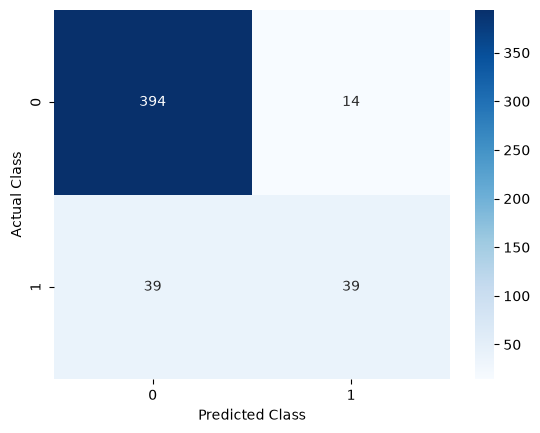

In [55]:
sns.heatmap(cm, annot=True , fmt="d", cmap="Blues")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

### Baseline Model Evaluation

The baseline Logistic Regression model achieved approximately 89% test accuracy and showed no clear overfitting. However, it performed much better for employees who stayed than for those who left. The attrition class achieved 74% precision but only 50% recall, meaning half of the actual attrition cases were missed. The next experiment will test balanced class weights to improve minority-class detection.

## Logistic Regression: Second Experiment

This second experiment adjusts the class weighting to improve prediction of the minority attrition class and compares the results with the baseline model.

In [56]:
model_2 = LogisticRegression(C=1, penalty="l2", solver="lbfgs", class_weight="balanced", max_iter=1000)

In [57]:
model_2.fit(x_train_processed, y_train)

d:\Projects\machine-learning-practice\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfg

In [58]:
y_hat = model_2.predict(x_test_processed)
y_hat_train = model_2.predict(x_train_processed)

In [59]:
print(f"Accuracy of the model with unseen data is: {accuracy_score(y_test, y_hat)}\n")
print(f"Accuracy of the model with seen data is {accuracy_score(y_train, y_hat_train)}")

Accuracy of the model with unseen data is: 0.7345679012345679

Accuracy of the model with seen data is 0.7784552845528455


In [60]:
print(f"Classification report\n")
print(classification_report(y_test, y_hat))

Classification report

              precision    recall  f1-score   support

          No       0.95      0.73      0.82       408
         Yes       0.35      0.78      0.49        78

    accuracy                           0.73       486
   macro avg       0.65      0.75      0.65       486
weighted avg       0.85      0.73      0.77       486



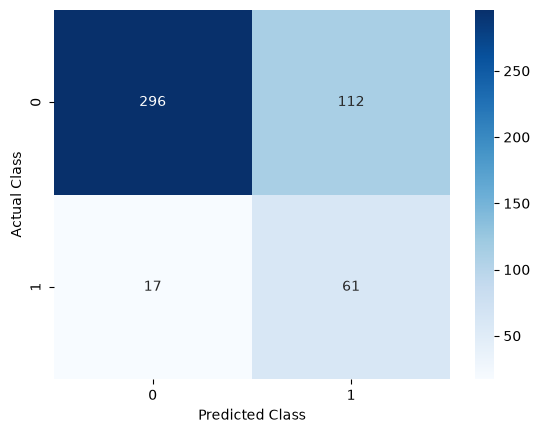

In [61]:
cm = confusion_matrix(y_test, y_hat)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()


### Second Model Evaluation

The second model produced lower overall accuracy and poor precision for the attrition class, resulting in many false alarms. However, its recall was more balanced across both classes, showing less bias toward the majority class. Further tuning will therefore focus on improving precision and overall performance while retaining stronger detection of employees who leave.

## Logistic Regression: Third Experiment

Because the balanced model produced more even recall across both classes, this experiment adjusts its regularization strength to improve precision and overall performance while preserving that balance.

In [64]:
model_3 = LogisticRegression(C=0.5, penalty="l2", solver="lbfgs", max_iter=1000, class_weight="balanced")

In [67]:
model_3.fit(x_train_processed, y_train)

d:\Projects\machine-learning-practice\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.5
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [73]:
y_hat = model_3.predict(x_test_processed)
y_hat_train = model_3.predict(x_train_processed)

In [74]:
print(f"The accuracy for the 3rd model with testing data is {accuracy_score(y_test, y_hat)}\n")
print(f"The accuracy for the 3rd model with training data is {accuracy_score(y_train, y_hat_train)}")

The accuracy for the 3rd model with testing data is 0.7345679012345679

The accuracy for the 3rd model with training data is 0.7774390243902439


In [75]:
print(f"Classification report\n {classification_report(y_test, y_hat)}")

Classification report
               precision    recall  f1-score   support

          No       0.95      0.72      0.82       408
         Yes       0.35      0.79      0.49        78

    accuracy                           0.73       486
   macro avg       0.65      0.76      0.66       486
weighted avg       0.85      0.73      0.77       486



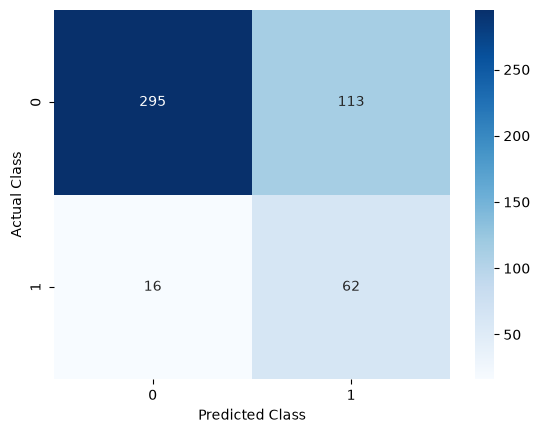

In [76]:
cm = confusion_matrix(y_test, y_hat)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

### Third Model Evaluation

Reducing `C` from `1.0` to `0.5` produced almost no meaningful change in accuracy, precision, recall, or the confusion matrix. Stronger L2 regularization therefore did not improve the balanced model, so the next experiment will test a different setting.

## Logistic Regression: Fourth Experiment

This experiment applies weaker L2 regularization by increasing `C` to examine whether giving the model more flexibility improves precision and overall performance.

In [77]:
model_4 = LogisticRegression(C=2, penalty="l2", solver="lbfgs", class_weight="balanced", max_iter=1000)

In [78]:
model_4.fit(x_train_processed, y_train)

d:\Projects\machine-learning-practice\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",2
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfg

In [79]:
y_hat = model_4.predict(x_test_processed)
y_hat_train = model_4.predict(x_train_processed)

In [80]:
print(f"The accuracy of the model with unseen data is {accuracy_score(y_test, y_hat)}")
print(f"The accuracy of the model with seen data is {accuracy_score(y_train, y_hat_train)}")

The accuracy of the model with unseen data is 0.7366255144032922
The accuracy of the model with seen data is 0.7754065040650406


In [81]:
print(f"Classification report\n {classification_report(y_test, y_hat)}")

Classification report
               precision    recall  f1-score   support

          No       0.95      0.73      0.82       408
         Yes       0.35      0.78      0.49        78

    accuracy                           0.74       486
   macro avg       0.65      0.75      0.66       486
weighted avg       0.85      0.74      0.77       486



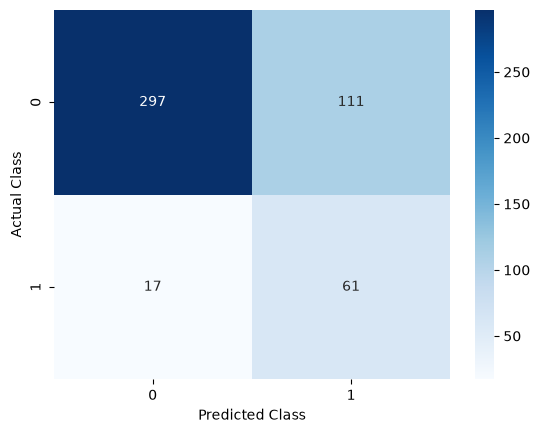

In [82]:
cm = confusion_matrix(y_test, y_hat)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

### Fourth Model Evaluation

Increasing `C` to apply weaker L2 regularization produced only a very small change in performance. Accuracy, precision, recall, and the confusion matrix remained almost unchanged, so adjusting regularization strength did not solve the false-positive problem.

The next experiment will test a different solver and L1 regularization before deciding whether to move beyond Logistic Regression.

## Logistic Regression: Fifth Experiment

This experiment replaces L2 regularization with L1 and uses the `liblinear` solver to test whether reducing weak feature coefficients to zero improves precision and overall model performance.

In [83]:
model_5 = LogisticRegression(C=1, penalty="l1", solver="liblinear", class_weight="balanced", max_iter=1000)

In [84]:
model_5.fit(x_train_processed, y_train)

d:\Projects\machine-learning-practice\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Projects\machine-learning-practice\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l1'
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"C C: float, default=1.0Inverse of regularization strength; must 

In [85]:
y_hat = model_5.predict(x_test_processed)
y_hat_train = model_5.predict(x_train_processed)

In [86]:
print(f"The accuracy of the model with unseen data is {accuracy_score(y_test, y_hat)}")
print(f"The accuracy of the model with seen data is {accuracy_score(y_train, y_hat_train)}")

The accuracy of the model with unseen data is 0.7304526748971193
The accuracy of the model with seen data is 0.7754065040650406


In [87]:
print(f"Classification report\n {classification_report(y_test, y_hat)}")

Classification report
               precision    recall  f1-score   support

          No       0.95      0.72      0.82       408
         Yes       0.35      0.78      0.48        78

    accuracy                           0.73       486
   macro avg       0.65      0.75      0.65       486
weighted avg       0.85      0.73      0.76       486



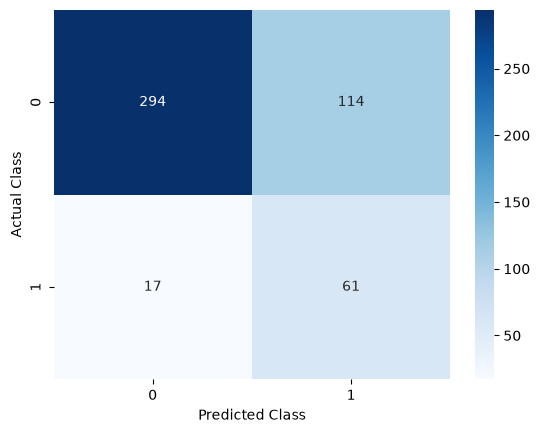

In [88]:
cm = confusion_matrix(y_test, y_hat)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

### Fifth Model Evaluation

Using L1 regularization with the `liblinear` solver produced no meaningful improvement. Accuracy, precision, recall, and the confusion matrix remained close to the previous balanced models, while false positives stayed high.

## Logistic Regression Conclusion

Among the five Logistic Regression experiments, Model 3 produced the most balanced performance across both classes, particularly in terms of recall. Although its overall accuracy and attrition precision were moderate, it reduced the bias toward the majority class more effectively than the other experiments.

Model 3 will therefore be used for feature contribution analysis to examine which features have the strongest and weakest influence on attrition prediction before making further feature-selection decisions.

--------
## Logistic Regression Feature Contribution Analysis

The parameter settings from Model 3 will be reused to examine the coefficients assigned to each processed feature. The coefficients will be matched with their feature names, converted to absolute values for comparison, and sorted to identify the strongest and weakest contributors to attrition prediction.

In [19]:
balanced_logistic_model =  LogisticRegression(C=0.5, penalty="l2", solver="lbfgs", max_iter=1000, class_weight="balanced")

In [20]:
balanced_logistic_model.fit(x_train_processed, y_train)

d:\Projects\machine-learning-practice\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.5
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [42]:
feature_coefficients = pd.DataFrame() 

In [57]:
coefficients = balanced_logistic_model.coef_
feature_coefficients["Coefficeints"] = coefficients[0]     

In [58]:
categorical_columns_encoded = encoder.get_feature_names_out().tolist()

In [59]:
feature_names = numerical_columns + categorical_columns_encoded
feature_coefficients["feature_names"] = feature_names

In [61]:
feature_coefficients.sort_values(by="Coefficeints", ascending=False)

,feature_names,Coefficeints
19,YearsAtCompany,0.851110
39,JobRole_Laboratory Technician,0.767981
50,OverTime_Yes,0.726648
48,MaritalStatus_Single,0.723096
34,EducationField_Technical Degree,0.629525
24,BusinessTravel_Travel_Frequently,0.605330
45,JobRole_Sales Representative,0.563029
28,Department_Sales,0.469640
38,JobRole_Human Resources,0.467631
11,NumCompaniesWorked,0.434170


### First Feature Elimination Experiment

Based on the coefficient analysis, three numerical features were selected for the first feature-removal experiment: `PerformanceRating`, `Education`, and `StockOptionLevel`. These features showed very small coefficient magnitudes and therefore appeared to contribute relatively little to the Logistic Regression model.

Only these three features will be removed initially so that the effect of feature elimination can be evaluated clearly before making any further removal decisions.

---------------
## Logistic Regression After Initial Feature Elimination

Based on the coefficient analysis, `PerformanceRating`, `Education`, and `StockOptionLevel` were identified as very weak contributors and selected for the first feature-removal experiment.

The data will now be prepared again without these three features, while keeping the same preprocessing approach, train-test split settings, and Model 3 Logistic Regression parameters. This will allow the new model performance to be compared fairly with the previous result and determine whether removing these weak features improves, reduces, or has little effect on prediction performance.

In [62]:
x = data[['Age','BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike','RelationshipSatisfaction','TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager']]

y = data['Attrition']

In [66]:
numerical_columns = x.select_dtypes(include='number').columns.tolist()
categorical_columns = x.select_dtypes(include="object").columns.tolist()

C:\Users\Admin\AppData\Local\Temp\ipykernel_29760\3494449301.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = x.select_dtypes(include="object").columns.tolist()


In [79]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.33, random_state=1)

In [80]:
x_train_scaled = scaler.fit_transform(x_train[numerical_columns])
x_test_scaled = scaler.transform(x_test[numerical_columns])

In [81]:
x_train_encoded = encoder.fit_transform(x_train[categorical_columns])
x_test_encoded = encoder.transform(x_test[categorical_columns])

In [82]:
x_train_processed = np.hstack((x_train_scaled,x_train_encoded))
x_test_processed = np.hstack((x_test_scaled, x_test_encoded))

In [83]:
reduced_feature_model = LogisticRegression(C=0.5, penalty="l2" ,solver="lbfgs", max_iter=1000, class_weight="balanced")

In [84]:
reduced_feature_model.fit(x_train_processed, y_train)

d:\Projects\machine-learning-practice\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.5
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [85]:
y_hat = reduced_feature_model.predict(x_test_processed)
y_hat_train = reduced_feature_model.predict(x_train_processed)

In [86]:
print(f"The accuracy of the model is {accuracy_score(y_test, y_hat)}")
print(f"The Training score of the model is {accuracy_score(y_train, y_hat_train)}")

The accuracy of the model is 0.7654320987654321
The Training score of the model is 0.7733739837398373


In [87]:
print("classification_report")
print(classification_report(y_test, y_hat))

classification_report
              precision    recall  f1-score   support

          No       0.95      0.76      0.84       401
         Yes       0.41      0.81      0.55        85

    accuracy                           0.77       486
   macro avg       0.68      0.78      0.69       486
weighted avg       0.86      0.77      0.79       486



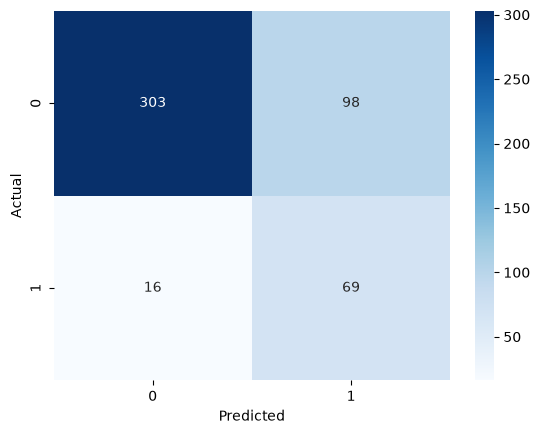

In [88]:
cm = confusion_matrix(y_test, y_hat)
sns.heatmap(cm , annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### First Feature Elimination Evaluation

After removing `PerformanceRating`, `Education`, and `StockOptionLevel`, the Logistic Regression model showed a clear improvement compared with Model 3. Test accuracy increased from approximately 73.7% to 76.5%, while precision, recall, and F1-score also improved for the attrition (`Yes`) class.

Attrition precision increased from 0.35 to 0.41 and recall increased from 0.78 to 0.81. The number of false positives decreased from 111 to 98, while false negatives also reduced slightly from 17 to 16.

Overall, the first feature-elimination experiment was successful. The reduced-feature model provides a better balance between the two classes and will therefore be used as the basis for further feature analysis and a second round of feature elimination.

## Coefficient and Feature Usefulness Evaluation

The coefficients of the reduced Logistic Regression model will now be examined to evaluate the contribution of each feature. This analysis will help identify the weakest remaining features and guide the next round of feature elimination.

In [91]:
feature_coefficients_2 = pd.DataFrame()

In [90]:
coefficients = reduced_feature_model.coef_

In [94]:
feature_coefficients_2["Coefficeints"] = coefficients[0]

In [96]:
categorical_columns_encoded = encoder.get_feature_names_out().tolist()

In [98]:
feature_names = numerical_columns + categorical_columns_encoded
feature_coefficients_2["Feature_Names"] = feature_names

In [102]:
feature_coefficients_2.sort_values(by="Coefficeints", ascending=False)

,Coefficeints,Feature_Names
42,0.785739,JobRole_Sales Representative
36,0.759113,JobRole_Laboratory Technician
47,0.750003,OverTime_Yes
31,0.739880,EducationField_Technical Degree
45,0.717328,MaritalStatus_Single
21,0.700503,BusinessTravel_Travel_Frequently
16,0.662497,YearsAtCompany
26,0.552707,EducationField_Human Resources
35,0.486027,JobRole_Human Resources
18,0.466673,YearsSinceLastPromotion


### Second-Round Feature Elimination

The updated coefficient analysis shows that `DailyRate`, `HourlyRate`, `MonthlyRate`, and `PercentSalaryHike` continue to make relatively small contributions to the Logistic Regression model. Although the rate-based features were initially retained in case they became useful when combined with other predictors, their coefficients remain weak. These four numerical features will therefore be removed in the second elimination round.

Some individual one-hot encoded categories also show very small coefficients. However, these will not be removed independently because they belong to broader categorical features such as `JobRole`, `MaritalStatus`, or `EducationField`. A categorical feature will only be considered for complete removal if its categories collectively show weak contribution to the model.